# Average-year streamflow vs USGS gages

Compare ParFlow **average** water-year forcing on **Potomac** (`potomac2`, WY **2005**) and **Wolf** (`wolf2`, WY **2008**) to USGS daily discharge.

**Gages (drainage-matched / config reference):**

| Domain | Water year | USGS site | Why this gage |
|--------|------------|-----------|---------------|
| Potomac | Oct 2004–Sep 2005 | `01608500` South Branch near Springfield, WV | ~1461 mi² — matches HUC `02070001` / domain outlet scale. Config `CURRENT_REFERENCE_GAGE` `01607500` is a ~103 mi² SF headwater and is shown only as a note. |
| Wolf | Oct 2007–Sep 2008 | `07030500` Wolf River at Rossville, TN | Config reference gage for HUC `08010210`. |

Model series come from a post-spinup **average** year of `droughts/short_baseline` (year index 40; same CW3E average WY each year). Gage lat/lon is mapped to CONUS2, then to the local domain, then **snapped to the nearest high-flow channel cell** (1 km grid).

Also validates **dry** forcing (config `DRY_YEAR`) at **drought start vs drought end** in `3_year_drought` / `10_year_drought`, to test whether antecedent drought years change skill vs USGS.

Uses **219 h** condensed `overland_flow` (m³/h). USGS daily values are block-averaged onto the same 219 h windows for metrics.

Also compares average-year skill **out of steady state** (y0) vs **end of transient spinup** (y39).


In [1]:
try:
    from drought_ensemble.analysis.paper_figures import utils
    from drought_ensemble.classes import Domain
except ImportError:
    import sys
    from pathlib import Path

    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))

    from analysis.paper_figures import utils
    from classes import Domain

from pathlib import Path

import hf_hydrodata as hf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from matplotlib.lines import Line2D

In [2]:
PROJECT_ROOT = Path("/glade/derecho/scratch/bwest/drought-ensemble")
FIG_DIR = PROJECT_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ENSEMBLE = "droughts"
MEMBER = "short_baseline"
INTERVAL = 219
STEPS_PER_YEAR = utils.ONE_YEAR // INTERVAL
SPINUP_YEAR_INDEX = 40  # first year after 40-yr average spinup
DROUGHT_LENGTHS = [3, 10]  # start vs end (1-yr has start==end)
CHANNEL_SNAP_RADIUS = 3  # cells; search for nearest high-flow cell

DOMAIN_LABELS = {"potomac2": "Potomac", "wolf2": "Wolf"}
LABEL_FS, LEGEND_FS, TITLE_FS = 12, 11, 13

# Drainage-appropriate validation gages (not always identical to config reference).
VALIDATION = {
    "potomac2": {
        "site_id": "01608500",
        "site_name": "South Branch Potomac near Springfield, WV",
        "drain_mi2": 1461,
        "note": "Config reference 01607500 is SF at Brandywine (~103 mi²).",
    },
    "wolf2": {
        "site_id": "07030500",
        "site_name": "Wolf River at Rossville, TN",
        "drain_mi2": 503,
        "note": "Matches domains/wolf2 CURRENT_REFERENCE_GAGE.",
    },
}

domains = {}
for name in VALIDATION:
    d = Domain(name, full_config_file_path_given=False)
    domains[name] = d
    print(
        f"{DOMAIN_LABELS[name]}: average WY {d.average_year}, "
        f"HUC {d.huc_id}, config gage {d.current_reference_gage}, "
        f"outlet (x,y)=({d.outlet_x}, {d.outlet_y})"
    )

Potomac: average WY 2005, HUC 02070001, config gage 01607500, outlet (x,y)=(66, 135)
Wolf: average WY 2008, HUC 08010210, config gage 07030500, outlet (x,y)=(18, 21)


## Helpers: domain origin, USGS DV, model year, metrics

In [3]:
CFS_TO_M3S = 0.028316846592
M3H_TO_M3S = 1.0 / 3600.0


def vegm_origin(domain_name: str) -> tuple[int, int]:
    """CONUS2 origin so NetCDF (x,y) ≈ from_latlon(lat,lon) - (i0, j0).

    ``drv_vegm.dat`` stores 1-based (i, j) with cell-center lat/lon. Empirically
    ``i0 = round(ci - i)`` maps gage lat/lon onto 0-based overland_flow indices.
    """
    vegm = (
        PROJECT_ROOT
        / "domains"
        / domain_name
        / "inputs"
        / f"{domain_name}_average"
        / "drv_vegm.dat"
    )
    with open(vegm) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                i, j = int(parts[0]), int(parts[1])
                lat, lon = float(parts[2]), float(parts[3])
            except ValueError:
                continue
            if i <= 0:
                continue
            ci, cj = hf.from_latlon("conus2", lat, lon)
            return int(round(ci - i)), int(round(cj - j))
    raise FileNotFoundError(f"No vegm grid points in {vegm}")


def usgs_site_latlon(site_id: str) -> tuple[float, float, str]:
    r = requests.get(
        "https://waterservices.usgs.gov/nwis/site/",
        params={
            "format": "rdb",
            "sites": site_id,
            "siteStatus": "all",
        },
        timeout=60,
    )
    r.raise_for_status()
    lines = [ln for ln in r.text.splitlines() if ln and not ln.startswith("#")]
    header, row = lines[0].split("\t"), lines[2].split("\t")
    d = dict(zip(header, row))
    return float(d["dec_lat_va"]), float(d["dec_long_va"]), d["station_nm"]


def usgs_daily_wy(site_id: str, water_year: int) -> pd.DataFrame:
    start = f"{water_year - 1}-10-01"
    end = f"{water_year}-09-30"
    r = requests.get(
        "https://waterservices.usgs.gov/nwis/dv/",
        params={
            "format": "json",
            "sites": site_id,
            "startDT": start,
            "endDT": end,
            "parameterCd": "00060",
            "siteStatus": "all",
        },
        timeout=60,
    )
    r.raise_for_status()
    series = r.json()["value"]["timeSeries"]
    if not series:
        raise ValueError(f"No DV streamflow for {site_id} {start}–{end}")
    vals = series[0]["values"][0]["value"]
    df = pd.DataFrame(vals)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.tz_localize(None)
    df["q_cfs"] = pd.to_numeric(df["value"], errors="coerce")
    df["q_m3s"] = df["q_cfs"] * CFS_TO_M3S
    return df[["date", "q_cfs", "q_m3s"]].dropna(subset=["q_m3s"])


def map_gage_to_local(
    domain_name: str, site_id: str, mean_flow_yx: np.ndarray
) -> dict:
    """Map USGS site → local (x,y), snapping to nearest high-flow cell."""
    lat, lon, station_nm = usgs_site_latlon(site_id)
    ci, cj = hf.from_latlon("conus2", lat, lon)
    i0, j0 = vegm_origin(domain_name)
    x0, y0 = int(round(ci - i0)), int(round(cj - j0))
    ny, nx = mean_flow_yx.shape

    best = None
    r = CHANNEL_SNAP_RADIUS
    for y in range(max(0, y0 - r), min(ny, y0 + r + 1)):
        for x in range(max(0, x0 - r), min(nx, x0 + r + 1)):
            q = float(mean_flow_yx[y, x])
            dist2 = (x - x0) ** 2 + (y - y0) ** 2
            # prefer higher flow, then closer cell
            key = (q, -dist2)
            if best is None or key > best[0]:
                best = (key, x, y, q)
    if best is None:
        raise ValueError(f"{site_id} maps outside {domain_name} mask neighborhood")
    _, x_s, y_s, q_s = best
    return {
        "site_id": site_id,
        "station_nm": station_nm,
        "lat": lat,
        "lon": lon,
        "conus2_i": ci,
        "conus2_j": cj,
        "local_x_raw": x0,
        "local_y_raw": y0,
        "local_x": x_s,
        "local_y": y_s,
        "snap_mean_m3h": q_s,
        "origin_ij": (i0, j0),
    }


def load_model_year_flow(
    domain_name: str, x: int, y: int, year_index: int, member: str = MEMBER
):
    """Return (hours, q_m3h, mean_field, path) for one condensed year."""
    files = utils._file_locations(
        ENSEMBLE, member, domain_name, start_year=0, interval=INTERVAL
    )
    path = files[year_index]
    with xr.open_dataset(path) as ds:
        q = np.asarray(ds["overland_flow"].isel(x=x, y=y).values, dtype=np.float64)
        mean_field = np.asarray(ds["overland_flow"].mean("time").values, dtype=np.float64)
    hours = np.arange(len(q), dtype=np.float64) * INTERVAL + INTERVAL / 2.0
    return hours, q, mean_field, path


def wy_timestamps(water_year: int, hours_from_wy_start: np.ndarray) -> pd.DatetimeIndex:
    origin = pd.Timestamp(f"{water_year - 1}-10-01")
    return origin + pd.to_timedelta(hours_from_wy_start, unit="h")


def block_mean_obs(obs: pd.DataFrame, model_times: pd.DatetimeIndex, half_window_h: float):
    """Average daily obs into windows centered on each model timestamp."""
    obs = obs.set_index("date").sort_index()
    out = np.full(len(model_times), np.nan)
    half = pd.Timedelta(hours=half_window_h)
    for i, t in enumerate(model_times):
        chunk = obs.loc[t - half : t + half, "q_m3s"]
        if len(chunk):
            out[i] = float(chunk.mean())
    return out


def flow_metrics(sim_m3s: np.ndarray, obs_m3s: np.ndarray) -> dict:
    mask = np.isfinite(sim_m3s) & np.isfinite(obs_m3s)
    s, o = sim_m3s[mask], obs_m3s[mask]
    if len(s) < 3:
        return {}
    bias = float(np.mean(s - o))
    pbias = 100.0 * bias / float(np.mean(o)) if np.mean(o) != 0 else np.nan
    rmse = float(np.sqrt(np.mean((s - o) ** 2)))
    denom = float(np.sum((o - np.mean(o)) ** 2))
    nse = float(1.0 - np.sum((s - o) ** 2) / denom) if denom > 0 else np.nan
    # RSR on log10 Q (Yang-style streamflow skill)
    s_log = np.log10(np.clip(s, 1e-6, None))
    o_log = np.log10(np.clip(o, 1e-6, None))
    rsr = float(
        np.sqrt(np.mean((s_log - o_log) ** 2)) / np.std(o_log, ddof=0)
    )
    corr = float(np.corrcoef(s, o)[0, 1])
    # Kling–Gupta Efficiency (Gupta et al. 2009)
    mu_s, mu_o = float(np.mean(s)), float(np.mean(o))
    sigma_s, sigma_o = float(np.std(s, ddof=0)), float(np.std(o, ddof=0))
    if mu_o == 0 or sigma_o == 0 or not np.isfinite(corr):
        kge = np.nan
    else:
        alpha = sigma_s / sigma_o
        beta = mu_s / mu_o
        kge = float(
            1.0
            - np.sqrt((corr - 1.0) ** 2 + (alpha - 1.0) ** 2 + (beta - 1.0) ** 2)
        )
    return {
        "n": int(mask.sum()),
        "sim_mean_m3s": float(np.mean(s)),
        "obs_mean_m3s": float(np.mean(o)),
        "bias_m3s": bias,
        "pbias_pct": pbias,
        "rmse_m3s": rmse,
        "nse": nse,
        "kge": kge,
        "rsr_log10": rsr,
        "r": corr,
    }

## Load model year + USGS for each domain

In [4]:
results = {}

for domain_name, meta in VALIDATION.items():
    d = domains[domain_name]
    wy = int(d.average_year)
    site_id = meta["site_id"]

    # Probe mean field at configured outlet first (path only), then remap gage
    hours, q_dummy, mean_field, path = load_model_year_flow(
        domain_name, int(d.outlet_x), int(d.outlet_y), SPINUP_YEAR_INDEX
    )
    loc = map_gage_to_local(domain_name, site_id, mean_field)
    hours, q_m3h, mean_field, path = load_model_year_flow(
        domain_name, loc["local_x"], loc["local_y"], SPINUP_YEAR_INDEX
    )

    times = wy_timestamps(wy, hours)
    sim_m3s = q_m3h * M3H_TO_M3S
    obs = usgs_daily_wy(site_id, wy)
    obs_on_model = block_mean_obs(obs, times, half_window_h=INTERVAL / 2.0)
    metrics = flow_metrics(sim_m3s, obs_on_model)

    # Monthly means on water-year calendar
    sim_df = pd.DataFrame({"date": times, "sim_m3s": sim_m3s, "obs_m3s": obs_on_model})
    sim_df["month"] = sim_df["date"].dt.to_period("M")
    monthly = sim_df.groupby("month", sort=True)[["sim_m3s", "obs_m3s"]].mean()

    results[domain_name] = {
        "wy": wy,
        "path": path,
        "loc": loc,
        "times": times,
        "sim_m3s": sim_m3s,
        "obs_daily": obs,
        "obs_on_model": obs_on_model,
        "metrics": metrics,
        "monthly": monthly,
        "outlet_xy": (int(d.outlet_x), int(d.outlet_y)),
        "meta": meta,
    }

    print(f"\n=== {DOMAIN_LABELS[domain_name]} WY{wy} vs USGS {site_id} ===")
    print(f"  {loc['station_nm']}")
    print(
        f"  mapped local raw (x,y)=({loc['local_x_raw']}, {loc['local_y_raw']}) "
        f"→ snapped ({loc['local_x']}, {loc['local_y']}); "
        f"config outlet {results[domain_name]['outlet_xy']}"
    )
    print(f"  model file: {path}")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4g}" if isinstance(v, float) else f"  {k}: {v}")
    if meta.get("note"):
        print(f"  note: {meta['note']}")


=== Potomac WY2005 vs USGS 01608500 ===
  SOUTH BRANCH POTOMAC RIVER NEAR SPRINGFIELD, WV
  mapped local raw (x,y)=(62, 127) → snapped (63, 129); config outlet (66, 135)
  model file: /glade/derecho/scratch/bwest/drought-ensemble/domains/potomac2/raw_runs/8b93a7721b39f66ffac1b903eb42ec0106c716a47c95118906aefb4a2710ef2b/processed_output_219h.nc
  n: 40
  sim_mean_m3s: 21.32
  obs_mean_m3s: 38.19
  bias_m3s: -16.88
  pbias_pct: -44.19
  rmse_m3s: 34.82
  nse: 0.04881
  kge: 0.3298
  rsr_log10: 4.141
  r: 0.5584
  note: Config reference 01607500 is SF at Brandywine (~103 mi²).



=== Wolf WY2008 vs USGS 07030500 ===
  WOLF RIVER AT ROSSVILLE, TN
  mapped local raw (x,y)=(26, 22) → snapped (23, 21); config outlet (18, 21)
  model file: /glade/derecho/scratch/bwest/drought-ensemble/domains/wolf2/raw_runs/8b93a7721b39f66ffac1b903eb42ec0106c716a47c95118906aefb4a2710ef2b/processed_output_219h.nc
  n: 40
  sim_mean_m3s: 25.65
  obs_mean_m3s: 18.34
  bias_m3s: 7.315
  pbias_pct: 39.89
  rmse_m3s: 16.56
  nse: 0.3984
  kge: 0.3296
  rsr_log10: 6.384
  r: 0.9355
  note: Matches domains/wolf2 CURRENT_REFERENCE_GAGE.


## Summary metrics

In [5]:
rows = []
for domain_name, res in results.items():
    m = res["metrics"]
    rows.append(
        {
            "Domain": DOMAIN_LABELS[domain_name],
            "WY": res["wy"],
            "USGS": res["loc"]["site_id"],
            "local (x,y)": f"({res['loc']['local_x']}, {res['loc']['local_y']})",
            "sim mean (m³/s)": m.get("sim_mean_m3s"),
            "obs mean (m³/s)": m.get("obs_mean_m3s"),
            "PBIAS (%)": m.get("pbias_pct"),
            "NSE": m.get("nse"),
            "KGE": m.get("kge"),
            "RSR log10": m.get("rsr_log10"),
            "r": m.get("r"),
        }
    )
summary = pd.DataFrame(rows)
summary

,Domain,WY,USGS,"local (x,y)",sim mean (m³/s),obs mean (m³/s),PBIAS (%),NSE,KGE,RSR log10,r
0,Potomac,2005,01608500,"(63, 129)",21.315113,38.193094,-44.191186,0.048811,0.329794,4.141412,0.558420
1,Wolf,2008,07030500,"(23, 21)",25.654200,18.338863,39.889805,0.398425,0.329645,6.383962,0.935472


## Hydrographs and monthly means

Columns = domains; rows = (219 h / daily overlay) and monthly means. Independent y-scales.

wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/average_year_usgs_hydrographs.png


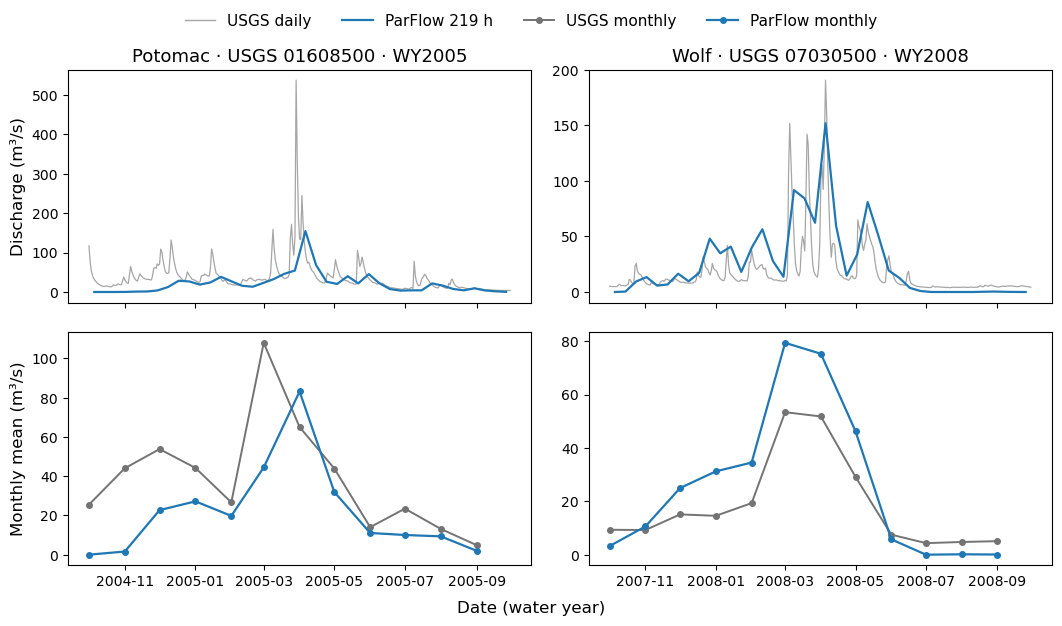

In [6]:
domain_order = ["potomac2", "wolf2"]
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.5, 6.2),
    sharex="col",
    constrained_layout=True,
)
fig.set_constrained_layout_pads(h_pad=0.06, w_pad=0.04, hspace=0.08, wspace=0.04)

for col, domain_name in enumerate(domain_order):
    res = results[domain_name]
    ax_ts, ax_mo = axes[0, col], axes[1, col]

    ax_ts.plot(
        res["obs_daily"]["date"],
        res["obs_daily"]["q_m3s"],
        color="0.65",
        lw=0.9,
        label="USGS daily",
    )
    ax_ts.plot(
        res["times"],
        res["sim_m3s"],
        color="C0",
        lw=1.6,
        label="ParFlow 219 h",
    )
    ax_ts.set_title(
        f"{DOMAIN_LABELS[domain_name]} · USGS {res['loc']['site_id']} · WY{res['wy']}",
        fontsize=TITLE_FS,
    )
    ax_ts.ticklabel_format(axis="y", style="plain", useOffset=False)

    months = res["monthly"].index.to_timestamp()
    ax_mo.plot(months, res["monthly"]["obs_m3s"], color="0.45", lw=1.4, marker="o", ms=4, label="USGS")
    ax_mo.plot(months, res["monthly"]["sim_m3s"], color="C0", lw=1.6, marker="o", ms=4, label="ParFlow")
    ax_mo.ticklabel_format(axis="y", style="plain", useOffset=False)

    if col == 0:
        ax_ts.set_ylabel("Discharge (m³/s)", fontsize=LABEL_FS)
        ax_mo.set_ylabel("Monthly mean (m³/s)", fontsize=LABEL_FS)

fig.supxlabel("Date (water year)", fontsize=LABEL_FS)
handles = [
    Line2D([0], [0], color="0.65", lw=1.0, label="USGS daily"),
    Line2D([0], [0], color="C0", lw=1.6, label="ParFlow 219 h"),
    Line2D([0], [0], color="0.45", lw=1.4, marker="o", ms=4, label="USGS monthly"),
    Line2D([0], [0], color="C0", lw=1.6, marker="o", ms=4, label="ParFlow monthly"),
]
fig.legend(handles=handles, loc="outside upper center", ncol=4, frameon=False, fontsize=LEGEND_FS)

out = FIG_DIR / "average_year_usgs_hydrographs.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()

## Simulated vs observed (219 h windows)

wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/average_year_usgs_scatter.png


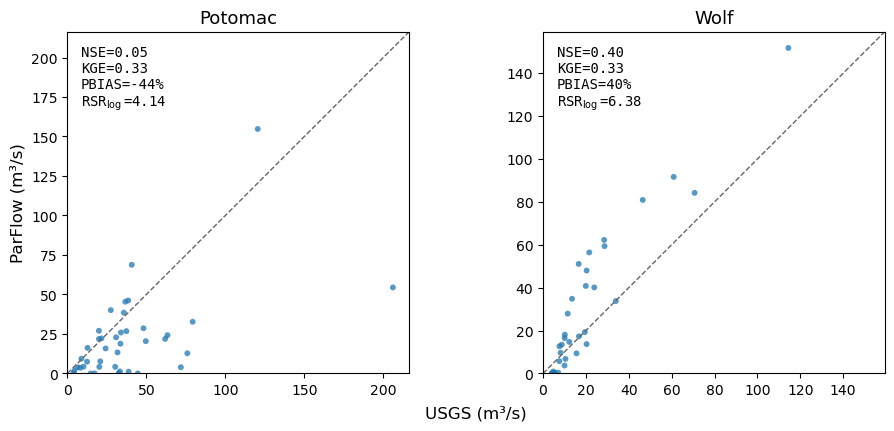

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), constrained_layout=True)

for ax, domain_name in zip(axes, domain_order):
    res = results[domain_name]
    s = res["sim_m3s"]
    o = res["obs_on_model"]
    mask = np.isfinite(s) & np.isfinite(o)
    ax.scatter(o[mask], s[mask], s=18, c="C0", alpha=0.75, edgecolors="none")
    lim = max(np.nanmax(o[mask]), np.nanmax(s[mask])) * 1.05
    ax.plot([0, lim], [0, lim], color="0.4", lw=1.0, ls="--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(DOMAIN_LABELS[domain_name], fontsize=TITLE_FS)
    m = res["metrics"]
    ax.text(
        0.04,
        0.96,
        f"NSE={m['nse']:.2f}\nKGE={m['kge']:.2f}\nPBIAS={m['pbias_pct']:.0f}%\nRSR$_{{\log}}$={m['rsr_log10']:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        family="monospace",
    )
    ax.ticklabel_format(style="plain", useOffset=False)

axes[0].set_ylabel("ParFlow (m³/s)", fontsize=LABEL_FS)
fig.supxlabel("USGS (m³/s)", fontsize=LABEL_FS)

out = FIG_DIR / "average_year_usgs_scatter.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()

## Gage cell on mean overland-flow field

Snapped gage cell (magenta) vs configured domain outlet (white).

wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/average_year_usgs_gage_cells.png


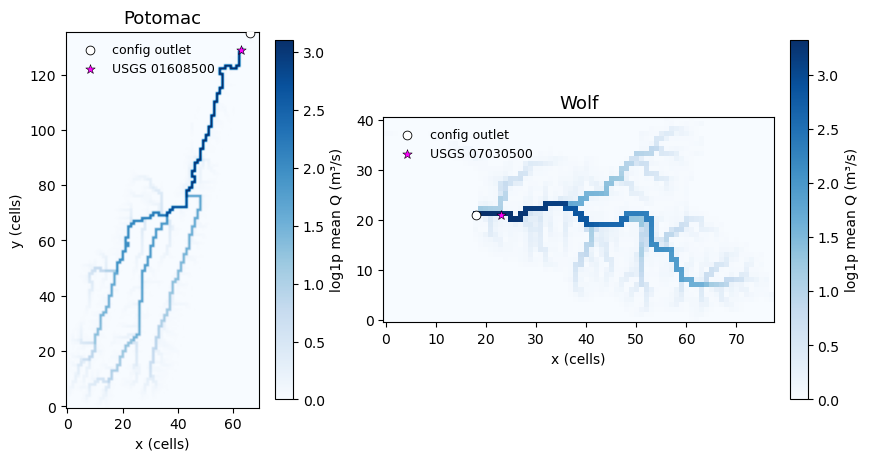

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

for ax, domain_name in zip(axes, domain_order):
    res = results[domain_name]
    _, _, mean_field, _ = load_model_year_flow(
        domain_name, res["loc"]["local_x"], res["loc"]["local_y"], SPINUP_YEAR_INDEX
    )
    # show log1p(m³/s) for dynamic range
    img = np.log1p(mean_field * M3H_TO_M3S)
    im = ax.imshow(img, origin="lower", cmap="Blues", aspect="equal")
    ox, oy = res["outlet_xy"]
    ax.scatter([ox], [oy], c="white", s=40, marker="o", edgecolors="k", lw=0.6, label="config outlet", zorder=3)
    ax.scatter(
        [res["loc"]["local_x"]],
        [res["loc"]["local_y"]],
        c="magenta",
        s=50,
        marker="*",
        edgecolors="k",
        lw=0.4,
        label=f"USGS {res['loc']['site_id']}",
        zorder=4,
    )
    ax.set_title(DOMAIN_LABELS[domain_name], fontsize=TITLE_FS)
    ax.set_xlabel("x (cells)")
    if domain_name == "potomac2":
        ax.set_ylabel("y (cells)")
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("log1p mean Q (m³/s)", fontsize=10)

out = FIG_DIR / "average_year_usgs_gage_cells.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()

## Drought-year validation (start vs end)

Same **dry** CW3E water year (`DRY_YEAR`: Potomac **1999**, Wolf **2007**) is repeated for each drought year. Compare USGS for that dry WY against:

- **start**: first drought year (index 40) — antecedent = average spinup
- **end**: last drought year (index `40 + L - 1`) — antecedent = `L-1` dry years

If metrics differ, initial conditions / storage memory from the previous year are affecting the dry-year hydrograph. Uses the same snapped gage cells as the average-year section; members `3_year_drought` and `10_year_drought`.

In [9]:
drought_results = {}  # (domain, L, phase) -> record

for domain_name, meta in VALIDATION.items():
    d = domains[domain_name]
    dry_wy = int(d.dry_year)
    site_id = meta["site_id"]
    # reuse snapped cell from average-year results
    loc = results[domain_name]["loc"]
    x, y = loc["local_x"], loc["local_y"]
    obs = usgs_daily_wy(site_id, dry_wy)

    for L in DROUGHT_LENGTHS:
        member = f"{L}_year_drought"
        phases = {
            "start": SPINUP_YEAR_INDEX,
            "end": SPINUP_YEAR_INDEX + L - 1,
        }
        for phase, year_index in phases.items():
            hours, q_m3h, _, path = load_model_year_flow(
                domain_name, x, y, year_index, member=member
            )
            times = wy_timestamps(dry_wy, hours)
            sim_m3s = q_m3h * M3H_TO_M3S
            obs_on_model = block_mean_obs(obs, times, half_window_h=INTERVAL / 2.0)
            metrics = flow_metrics(sim_m3s, obs_on_model)
            sim_df = pd.DataFrame(
                {"date": times, "sim_m3s": sim_m3s, "obs_m3s": obs_on_model}
            )
            sim_df["month"] = sim_df["date"].dt.to_period("M")
            monthly = sim_df.groupby("month", sort=True)[["sim_m3s", "obs_m3s"]].mean()

            key = (domain_name, L, phase)
            drought_results[key] = {
                "wy": dry_wy,
                "member": member,
                "year_index": year_index,
                "path": path,
                "loc": loc,
                "times": times,
                "sim_m3s": sim_m3s,
                "obs_daily": obs,
                "obs_on_model": obs_on_model,
                "metrics": metrics,
                "monthly": monthly,
            }
            m = metrics
            print(
                f"{DOMAIN_LABELS[domain_name]} {member} {phase} "
                f"(idx={year_index}, dry WY{dry_wy}): "
                f"NSE={m['nse']:.3f} KGE={m['kge']:.3f} "
                f"PBIAS={m['pbias_pct']:.1f}% r={m['r']:.3f}"
            )


Potomac 3_year_drought start (idx=40, dry WY1999): NSE=0.187 KGE=0.521 PBIAS=-29.4% r=0.621
Potomac 3_year_drought end (idx=42, dry WY1999): NSE=0.228 KGE=0.507 PBIAS=-32.3% r=0.630
Potomac 10_year_drought start (idx=40, dry WY1999): NSE=0.187 KGE=0.521 PBIAS=-29.4% r=0.621
Potomac 10_year_drought end (idx=49, dry WY1999): NSE=0.226 KGE=0.501 PBIAS=-32.9% r=0.628


Wolf 3_year_drought start (idx=40, dry WY2007): NSE=-0.276 KGE=0.175 PBIAS=-27.7% r=0.849
Wolf 3_year_drought end (idx=42, dry WY2007): NSE=-0.108 KGE=0.417 PBIAS=-52.2% r=0.762
Wolf 10_year_drought start (idx=40, dry WY2007): NSE=-0.276 KGE=0.175 PBIAS=-27.7% r=0.849
Wolf 10_year_drought end (idx=49, dry WY2007): NSE=-0.112 KGE=0.413 PBIAS=-52.8% r=0.763


### Drought start vs end metrics

Δ columns are **end − start** (positive ΔNSE/ΔKGE ⇒ skill improves after prior dry years).

In [10]:
rows = []
for domain_name in DOMAIN_LABELS:
    for L in DROUGHT_LENGTHS:
        start = drought_results[(domain_name, L, "start")]["metrics"]
        end = drought_results[(domain_name, L, "end")]["metrics"]
        rows.append(
            {
                "Domain": DOMAIN_LABELS[domain_name],
                "Drought L": L,
                "Dry WY": drought_results[(domain_name, L, "start")]["wy"],
                "USGS": results[domain_name]["loc"]["site_id"],
                "start NSE": start.get("nse"),
                "end NSE": end.get("nse"),
                "ΔNSE": end.get("nse", float("nan")) - start.get("nse", float("nan")),
                "start KGE": start.get("kge"),
                "end KGE": end.get("kge"),
                "ΔKGE": end.get("kge", float("nan")) - start.get("kge", float("nan")),
                "start PBIAS": start.get("pbias_pct"),
                "end PBIAS": end.get("pbias_pct"),
                "start r": start.get("r"),
                "end r": end.get("r"),
            }
        )
drought_summary = pd.DataFrame(rows)
drought_summary


,Domain,Drought L,Dry WY,USGS,start NSE,end NSE,ΔNSE,start KGE,end KGE,ΔKGE,start PBIAS,end PBIAS,start r,end r
0,Potomac,3,1999,01608500,0.18660,0.227829,0.041229,0.520510,0.506864,-0.013646,-29.369003,-32.283116,0.620988,0.630101
1,Potomac,10,1999,01608500,0.18660,0.226068,0.039469,0.520510,0.500746,-0.019764,-29.369003,-32.902201,0.620988,0.628243
2,Wolf,3,2007,07030500,-0.27562,-0.108322,0.167298,0.174983,0.416550,0.241567,-27.733509,-52.176773,0.848533,0.762379
3,Wolf,10,2007,07030500,-0.27562,-0.112005,0.163616,0.174983,0.413379,0.238396,-27.733509,-52.808823,0.848533,0.763137


### Hydrographs: drought start vs end vs USGS

Columns = domains; rows = drought lengths. Grey = USGS daily; blue = drought **start**; brown = drought **end**.

wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/drought_year_usgs_start_vs_end_hydrographs.png


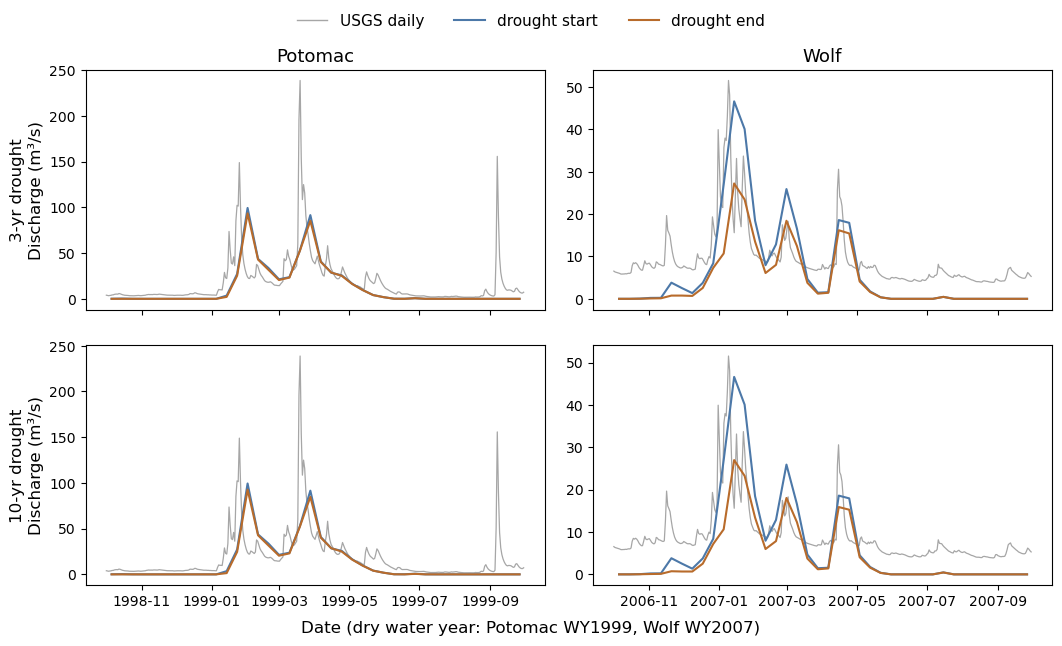

In [11]:
domain_order = ["potomac2", "wolf2"]
COLORS_PHASE = {"start": "#4C78A8", "end": "#B86B2B"}

fig, axes = plt.subplots(
    len(DROUGHT_LENGTHS),
    2,
    figsize=(10.5, 3.2 * len(DROUGHT_LENGTHS)),
    sharex="col",
    constrained_layout=True,
)
fig.set_constrained_layout_pads(h_pad=0.06, w_pad=0.04, hspace=0.08, wspace=0.04)
if len(DROUGHT_LENGTHS) == 1:
    axes = np.asarray(axes).reshape(1, 2)

for row, L in enumerate(DROUGHT_LENGTHS):
    for col, domain_name in enumerate(domain_order):
        ax = axes[row, col]
        obs = drought_results[(domain_name, L, "start")]["obs_daily"]
        ax.plot(obs["date"], obs["q_m3s"], color="0.65", lw=0.9, label="USGS daily")
        for phase in ("start", "end"):
            res = drought_results[(domain_name, L, phase)]
            ax.plot(
                res["times"],
                res["sim_m3s"],
                color=COLORS_PHASE[phase],
                lw=1.5,
                label=f"drought {phase} (yr {res['year_index']})",
            )
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        if row == 0:
            ax.set_title(DOMAIN_LABELS[domain_name], fontsize=TITLE_FS)
        if col == 0:
            ax.set_ylabel(f"{L}-yr drought\nDischarge (m³/s)", fontsize=LABEL_FS)

fig.supxlabel(
    "Date (dry water year: Potomac WY1999, Wolf WY2007)", fontsize=LABEL_FS
)
handles = [
    Line2D([0], [0], color="0.65", lw=1.0, label="USGS daily"),
    Line2D([0], [0], color=COLORS_PHASE["start"], lw=1.5, label="drought start"),
    Line2D([0], [0], color=COLORS_PHASE["end"], lw=1.5, label="drought end"),
]
fig.legend(
    handles=handles,
    loc="outside upper center",
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FS,
)

out = FIG_DIR / "drought_year_usgs_start_vs_end_hydrographs.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()


### Scatter: start vs end (same USGS dry year)

wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/drought_year_usgs_start_vs_end_scatter.png


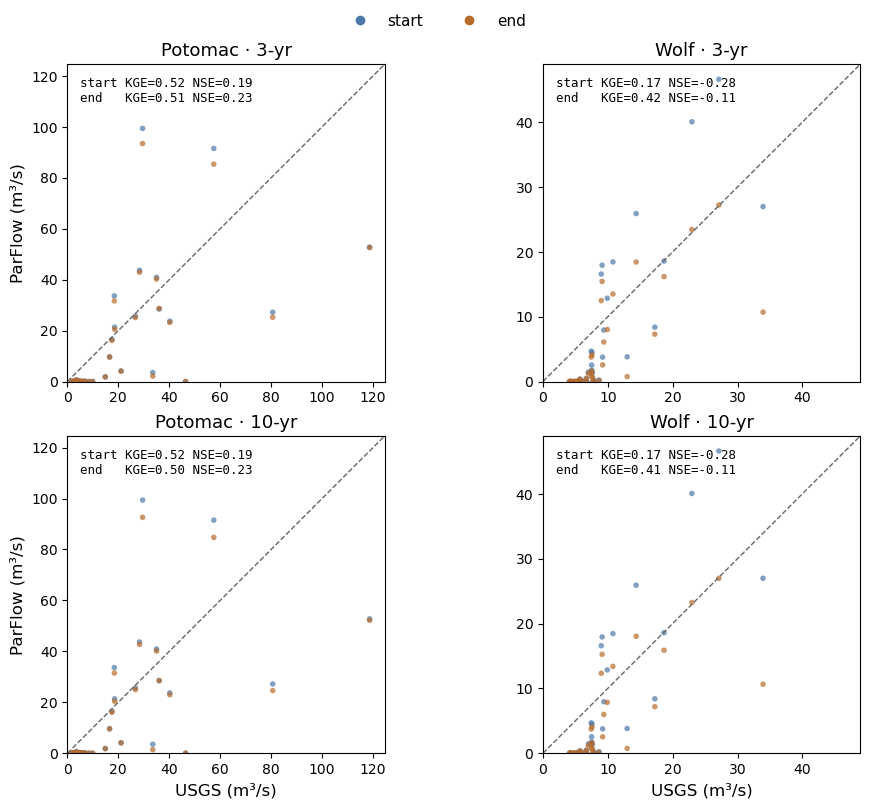

In [12]:
fig, axes = plt.subplots(
    len(DROUGHT_LENGTHS),
    2,
    figsize=(9.5, 4.0 * len(DROUGHT_LENGTHS)),
    constrained_layout=True,
)
if len(DROUGHT_LENGTHS) == 1:
    axes = np.asarray(axes).reshape(1, 2)

for row, L in enumerate(DROUGHT_LENGTHS):
    for col, domain_name in enumerate(domain_order):
        ax = axes[row, col]
        lim = 0.0
        for phase in ("start", "end"):
            res = drought_results[(domain_name, L, phase)]
            s, o = res["sim_m3s"], res["obs_on_model"]
            mask = np.isfinite(s) & np.isfinite(o)
            ax.scatter(
                o[mask],
                s[mask],
                s=16,
                c=COLORS_PHASE[phase],
                alpha=0.7,
                edgecolors="none",
                label=phase,
            )
            lim = max(lim, np.nanmax(o[mask]), np.nanmax(s[mask]))
        lim *= 1.05
        ax.plot([0, lim], [0, lim], color="0.4", lw=1.0, ls="--")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect("equal", adjustable="box")
        st = drought_results[(domain_name, L, "start")]["metrics"]
        en = drought_results[(domain_name, L, "end")]["metrics"]
        ax.set_title(
            f"{DOMAIN_LABELS[domain_name]} · {L}-yr",
            fontsize=TITLE_FS,
        )
        ax.text(
            0.04,
            0.96,
            f"start KGE={st['kge']:.2f} NSE={st['nse']:.2f}\n"
            f"end   KGE={en['kge']:.2f} NSE={en['nse']:.2f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            family="monospace",
        )
        ax.ticklabel_format(style="plain", useOffset=False)
        if col == 0:
            ax.set_ylabel("ParFlow (m³/s)", fontsize=LABEL_FS)
        if row == len(DROUGHT_LENGTHS) - 1:
            ax.set_xlabel("USGS (m³/s)", fontsize=LABEL_FS)

handles = [
    Line2D([0], [0], color=COLORS_PHASE["start"], marker="o", ls="none", label="start"),
    Line2D([0], [0], color=COLORS_PHASE["end"], marker="o", ls="none", label="end"),
]
fig.legend(
    handles=handles, loc="outside upper center", ncol=2, frameon=False, fontsize=LEGEND_FS
)

out = FIG_DIR / "drought_year_usgs_start_vs_end_scatter.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()


## Average year: out of steady state vs end of transient spinup

Same average WY and gage cell as above. Compare:

- **out of SS** — year index **0** (first average year after steady-state PME IC)
- **end of transient spinup** — year index **39** (40th / last spinup year)
- **post-spinup y40** — year index **40** (reference used in the average-year section; should match y39 if spun up)


In [13]:
SPINUP_COMPARE = {
    "out_of_ss": 0,
    "end_transient_spinup": 39,
    "post_spinup_y40": 40,
}

spinup_results = {}  # (domain, phase) -> record

for domain_name, meta in VALIDATION.items():
    d = domains[domain_name]
    wy = int(d.average_year)
    loc = results[domain_name]["loc"]
    x, y = loc["local_x"], loc["local_y"]
    obs = usgs_daily_wy(meta["site_id"], wy)

    for phase, year_index in SPINUP_COMPARE.items():
        hours, q_m3h, _, path = load_model_year_flow(
            domain_name, x, y, year_index, member=MEMBER
        )
        times = wy_timestamps(wy, hours)
        sim_m3s = q_m3h * M3H_TO_M3S
        obs_on_model = block_mean_obs(obs, times, half_window_h=INTERVAL / 2.0)
        metrics = flow_metrics(sim_m3s, obs_on_model)
        spinup_results[(domain_name, phase)] = {
            "wy": wy,
            "year_index": year_index,
            "path": path,
            "times": times,
            "sim_m3s": sim_m3s,
            "obs_daily": obs,
            "obs_on_model": obs_on_model,
            "metrics": metrics,
        }
        m = metrics
        print(
            f"{DOMAIN_LABELS[domain_name]:7s} {phase:22s} y{year_index:2d}: "
            f"NSE={m['nse']:.3f} KGE={m['kge']:.3f} "
            f"PBIAS={m['pbias_pct']:.1f}% r={m['r']:.3f} "
            f"sim={m['sim_mean_m3s']:.2f}"
        )


Potomac out_of_ss              y 0: NSE=0.336 KGE=0.600 PBIAS=-15.7% r=0.649 sim=32.21
Potomac end_transient_spinup   y39: NSE=0.049 KGE=0.330 PBIAS=-44.2% r=0.558 sim=21.32
Potomac post_spinup_y40        y40: NSE=0.049 KGE=0.330 PBIAS=-44.2% r=0.558 sim=21.32


Wolf    out_of_ss              y 0: NSE=0.199 KGE=0.202 PBIAS=58.8% r=0.914 sim=29.12
Wolf    end_transient_spinup   y39: NSE=0.398 KGE=0.330 PBIAS=39.9% r=0.935 sim=25.65
Wolf    post_spinup_y40        y40: NSE=0.398 KGE=0.330 PBIAS=39.9% r=0.935 sim=25.65


In [14]:
rows = []
for domain_name in DOMAIN_LABELS:
    ss = spinup_results[(domain_name, "out_of_ss")]["metrics"]
    end = spinup_results[(domain_name, "end_transient_spinup")]["metrics"]
    y40 = spinup_results[(domain_name, "post_spinup_y40")]["metrics"]
    rows.append(
        {
            "Domain": DOMAIN_LABELS[domain_name],
            "Avg WY": spinup_results[(domain_name, "out_of_ss")]["wy"],
            "SS NSE": ss["nse"],
            "end NSE": end["nse"],
            "ΔNSE": end["nse"] - ss["nse"],
            "SS KGE": ss["kge"],
            "end KGE": end["kge"],
            "ΔKGE": end["kge"] - ss["kge"],
            "SS PBIAS": ss["pbias_pct"],
            "end PBIAS": end["pbias_pct"],
            "y40 KGE": y40["kge"],
        }
    )
spinup_summary = pd.DataFrame(rows)
spinup_summary


,Domain,Avg WY,SS NSE,end NSE,ΔNSE,SS KGE,end KGE,ΔKGE,SS PBIAS,end PBIAS,y40 KGE
0,Potomac,2005,0.335921,0.049026,-0.286896,0.600200,0.329938,-0.270262,-15.677246,-44.172224,0.329794
1,Wolf,2008,0.199313,0.398399,0.199086,0.202479,0.329590,0.127111,58.779051,39.891764,0.329645


wrote /glade/derecho/scratch/bwest/drought-ensemble/analysis/figures/average_year_usgs_ss_vs_end_spinup.png


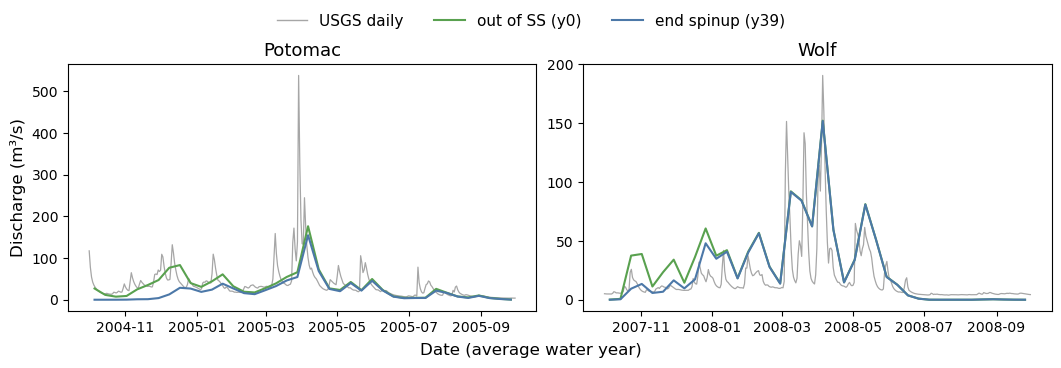

In [15]:
COLORS_SPIN = {
    "out_of_ss": "#59A14F",
    "end_transient_spinup": "#4C78A8",
}
domain_order = ["potomac2", "wolf2"]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharex=False, constrained_layout=True)
for ax, domain_name in zip(axes, domain_order):
    obs = spinup_results[(domain_name, "out_of_ss")]["obs_daily"]
    ax.plot(obs["date"], obs["q_m3s"], color="0.65", lw=0.9, label="USGS daily")
    for phase, label in [
        ("out_of_ss", "out of SS (y0)"),
        ("end_transient_spinup", "end spinup (y39)"),
    ]:
        res = spinup_results[(domain_name, phase)]
        ax.plot(
            res["times"],
            res["sim_m3s"],
            color=COLORS_SPIN[phase],
            lw=1.5,
            label=label,
        )
    ax.set_title(DOMAIN_LABELS[domain_name], fontsize=TITLE_FS)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[0].set_ylabel("Discharge (m³/s)", fontsize=LABEL_FS)
fig.supxlabel("Date (average water year)", fontsize=LABEL_FS)
handles = [
    Line2D([0], [0], color="0.65", lw=1.0, label="USGS daily"),
    Line2D([0], [0], color=COLORS_SPIN["out_of_ss"], lw=1.5, label="out of SS (y0)"),
    Line2D(
        [0], [0], color=COLORS_SPIN["end_transient_spinup"], lw=1.5, label="end spinup (y39)"
    ),
]
fig.legend(
    handles=handles, loc="outside upper center", ncol=3, frameon=False, fontsize=LEGEND_FS
)
out = FIG_DIR / "average_year_usgs_ss_vs_end_spinup.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("wrote", out)
plt.show()
